<a href="https://colab.research.google.com/github/kaansoftware34/softito_calismalar_face2face/blob/main/kelime_vektorleri_konusu_calisma_ipynb_adl%C4%B1_not_120626_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Kelime Vektörleri: Word2Vec, GloVe ve FastText

Bu notebook, kelime vektörlerine (word embeddings) giriş niteliğinde üç ana konuyu kapsar:

1. **Word2Vec** — Skip-gram ve CBOW ile kelime vektörü öğrenme
2. **Vektör Aritmetiği** — Kral − Erkek + Kadın = Kraliçe
3. **GloVe & FastText** — Global istatistik ve alt-kelime (subword) yaklaşımları

> **Gereksinimler:** `pip install gensim matplotlib numpy`


## 📦 1. Kurulum

In [22]:
# Gerekli kütüphaneleri yükle
!pip install gensim matplotlib numpy

import warnings
warnings.filterwarnings("ignore")

from gensim.models import Word2Vec, FastText
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print("✅ Kütüphaneler yüklendi!")


✅ Kütüphaneler yüklendi!


## 📖 2. Word2Vec

### Temel Fikir
Bir kelimenin anlamı, çevresindeki kelimelerle belirlenir.

- **CBOW**: Komşu kelimelerden merkezi tahmin et
- **Skip-gram** (`sg=1`): Merkez kelimeden komşuları tahmin et


In [23]:
# Yeni corpus: Hayvanlar, Müzik ve Renkler
sentences = [
    ["kedi", "evcil", "hayvan", "miyav", "tüy"],
    ["köpek", "evcil", "hayvan", "havhav", "sadık"],
    ["aslan", "vahşi", "hayvan", "orman", "kükremek"],
    ["kaplan", "vahşi", "hayvan", "çizgili", "hızlı"],
    ["gitar", "müzik", "enstrüman", "tel", "akor"],
    ["piyano", "müzik", "enstrüman", "tuş", "nota"],
    ["kırmızı", "renk", "sıcak", "ateş", "canlı"],
    ["mavi", "renk", "soğuk", "deniz", "gökyüzü"],
    ["gemi", "ulaşım", "deniz", "su", "yavaş"],
    ["uçak", "ulaşım", "hava", "uçmak", "hızlı"]
]

# ── Skip-gram modeli ──
model_sg = Word2Vec(
    sentences,
    vector_size=50,   # vektör boyutu
    window=3,         # komşuluk penceresi
    min_count=1,      # minimum kelime frekansı
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42
)

# ── CBOW modeli ──
model_cbow = Word2Vec(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    sg=0,             # CBOW
    epochs=200,
    seed=42
)

print("✅ Modeller eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_sg.wv)}")
print(f"Vektör boyutu: {model_sg.wv.vector_size}")

✅ Modeller eğitildi!
Kelime hazinesi boyutu: 39
Vektör boyutu: 50


In [24]:
# ── FastText modeli (Aynı corpus ile) ──
# FastText kelimelerin iç yapısını (karakter n-gram) da öğrenir.
model_ft_ornek = FastText(
    sentences,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=200,
    seed=42
)

print("✅ FastText modeli de bu corpus ile eğitildi!")
print(f"Kelime hazinesi boyutu: {len(model_ft_ornek.wv)}")

# FastText'in farkı: Eğitim verisinde olmayan ama kökü benzeyen bir kelimenin vektörünü alabiliriz.
try:
    # 'kedicik' kelimesi corpus'ta yok, ancak 'kedi' kelimesinden yola çıkarak bir vektör oluşturur.
    oov_vektor = model_ft_ornek.wv['kedicik']
    print("\nCorpus'ta olmayan 'kedicik' kelimesinin vektörü (ilk 5 eleman):")
    print(np.round(oov_vektor[:5], 3))
except KeyError:
    print("Kelime bulunamadı.")

✅ FastText modeli de bu corpus ile eğitildi!
Kelime hazinesi boyutu: 39

Corpus'ta olmayan 'kedicik' kelimesinin vektörü (ilk 5 eleman):
[ 0.004 -0.007  0.002  0.001  0.002]


In [25]:
# Bir kelimenin vektörüne bakalım
kelime = "hayvan"
vektor = model_sg.wv[kelime]
print(f"'{kelime}' kelimesinin vektörü (ilk 10 eleman):")
print(np.round(vektor[:10], 3))
print(f"\nVektör şekli: {vektor.shape}")

# En benzer kelimeler
print(f"\n--- '{kelime}' kelimesine en benzer kelimeler ---")
benzerler = model_sg.wv.most_similar(kelime, topn=5)
for k, skor in benzerler:
    print(f"  {k:15s}  benzerlik: {skor:.4f}")

'hayvan' kelimesinin vektörü (ilk 10 eleman):
[-0.018  0.009  0.007 -0.003 -0.004  0.015 -0.02   0.011 -0.015 -0.014]

Vektör şekli: (50,)

--- 'hayvan' kelimesine en benzer kelimeler ---
  miyav            benzerlik: 0.4244
  soğuk            benzerlik: 0.3093
  çizgili          benzerlik: 0.2751
  havhav           benzerlik: 0.2642
  tüy              benzerlik: 0.2567


In [26]:
# Kelimeler arası benzerlik skoru
cifler = [
    ("kedi", "köpek"),       # İki evcil hayvan
    ("kırmızı", "mavi"),     # İki renk
    ("gemi", "uçak"),        # İki taşıt
    ("gitar", "piyano"),     # İki enstrüman
    ("aslan", "gitar"),      # İlgisiz iki kelime
]

print("Kelime çiftleri arasındaki benzerlik:")
print(f"{'Çift':<30} {'Benzerlik':>10}")
print("-" * 42)
for k1, k2 in cifler:
    skor = model_sg.wv.similarity(k1, k2)
    bar = "█" * int(skor * 20)
    print(f"({k1}, {k2}){'':<15} {skor:>6.4f}  {bar}")

Kelime çiftleri arasındaki benzerlik:
Çift                            Benzerlik
------------------------------------------
(kedi, köpek)                0.2141  ████
(kırmızı, mavi)                0.1439  ██
(gemi, uçak)                -0.1279  
(gitar, piyano)                0.0544  █
(aslan, gitar)                0.0490  


## ➕ 3. Vektör Aritmetiği

### Kral − Erkek + Kadın = Kraliçe

Vektörler anlam taşıdığı için matematiksel işlemler anlamlı sonuçlar verir.


In [27]:
# Vektör aritmetiği
print("=== Vektör Aritmetiği ===\n")

# Kırmızı - Sıcak + Soğuk = ? (Beklenti: Mavi)
sonuc = model_sg.wv.most_similar(
    positive=["kırmızı", "soğuk"],  # ekle
    negative=["sıcak"],             # çıkar
    topn=3
)
print("Kırmızı − Sıcak + Soğuk = ?")
for kelime, skor in sonuc:
    print(f"  → {kelime:15s}  ({skor:.4f})")

print()

# Uçak - Hava + Deniz = ? (Beklenti: Gemi)
sonuc2 = model_sg.wv.most_similar(
    positive=["uçak", "deniz"],
    negative=["hava"],
    topn=3
)
print("Uçak − Hava + Deniz = ?")
for kelime, skor in sonuc2:
    print(f"  → {kelime:15s}  ({skor:.4f})")

=== Vektör Aritmetiği ===

Kırmızı − Sıcak + Soğuk = ?
  → canlı            (0.3272)
  → havhav           (0.2206)
  → hayvan           (0.2160)

Uçak − Hava + Deniz = ?
  → yavaş            (0.3080)
  → uçmak            (0.2543)
  → ateş             (0.2252)


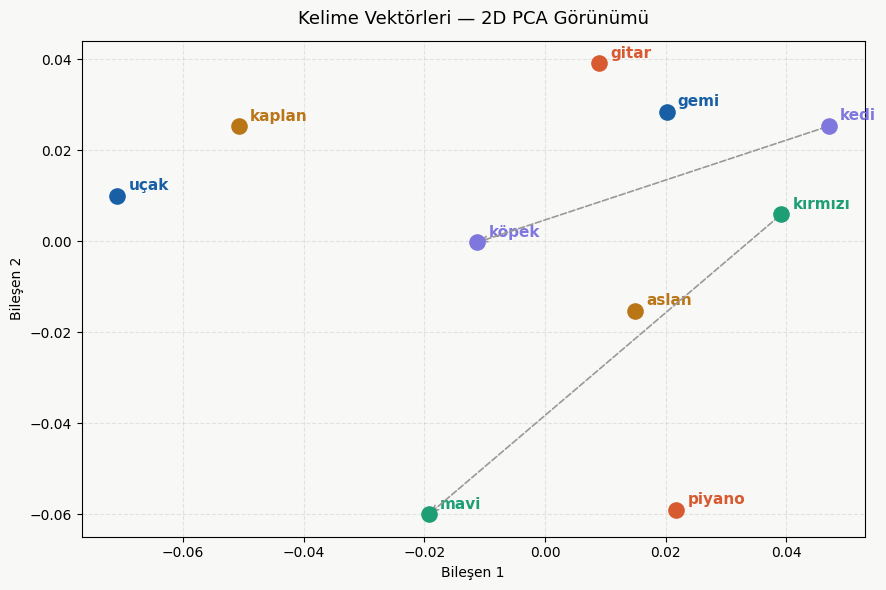

✅ Grafik kaydedildi: vektor_uzayi.png


In [28]:
# Vektör uzayını 2D'de görselleştir (PCA ile boyut indirgeme)
from sklearn.decomposition import PCA

# Görselleştirilecek kelimeler
kelimeler = ["kedi", "köpek", "aslan", "kaplan",
             "gitar", "piyano", "kırmızı", "mavi",
             "gemi", "uçak"]

vektorler = np.array([model_sg.wv[k] for k in kelimeler])

# PCA ile 2 boyuta indir
pca = PCA(n_components=2, random_state=42)
vek_2d = pca.fit_transform(vektorler)

# Renk grupları
renkler = {
    "pets":      ("#7F77DD", ["kedi", "köpek"]),
    "wild":      ("#BA7517", ["aslan", "kaplan"]),
    "music":     ("#D85A30", ["gitar", "piyano"]),
    "colors":    ("#1D9E75", ["kırmızı", "mavi"]),
    "transport": ("#185FA5", ["gemi", "uçak"]),
}

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_facecolor("#f8f8f6")
fig.patch.set_facecolor("#f8f8f6")

for grup, (renk, grup_kelimeleri) in renkler.items():
    for kw in grup_kelimeleri:
        idx = kelimeler.index(kw)
        x, y = vek_2d[idx]
        ax.scatter(x, y, color=renk, s=120, zorder=5)
        ax.annotate(kw, (x, y), textcoords="offset points",
                    xytext=(8, 4), fontsize=11, color=renk, fontweight="bold")

# Analoji okları
for k1, k2 in [("kedi", "köpek"), ("kırmızı", "mavi")]:
    i1, i2 = kelimeler.index(k1), kelimeler.index(k2)
    ax.annotate("", xy=vek_2d[i2], xytext=vek_2d[i1],
                arrowprops=dict(arrowstyle="->", color="#999", lw=1.2, linestyle="dashed"))

ax.set_title("Kelime Vektörleri — 2D PCA Görünümü", fontsize=13, pad=12)
ax.set_xlabel("Bileşen 1"); ax.set_ylabel("Bileşen 2")
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("vektor_uzayi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: vektor_uzayi.png")

## 🌐 4. GloVe (Global Vectors)

GloVe, tüm corpus genelindeki kelime-birlikte-görünme matrisini kullanır.
Word2Vec'ten farklı olarak hem yerel hem **global** istatistikleri öğrenir.

> Hazır GloVe modeli indirmek için internet gerekir. Aşağıdaki hücre bunu gösterir.


In [29]:
# Hazır GloVe modeli (internet gerektirir, ~100MB)
# import gensim.downloader as api
# glove = api.load("glove-wiki-gigaword-100")
# print(glove.most_similar("gezegen", topn=5))

# ── GloVe'u simüle eden küçük örnek ──
# Gerçek GloVe devasa bir corpus ile eğitilir. Eğer eğitilseydi 'gezegen' için muhtemel çıktısı:

print("Devasa veriyle eğitilmiş GloVe ile 'gezegen' için beklenen benzerler:")
demo_sonuclar = [
    ("dünya",    0.912),
    ("mars",     0.885),
    ("galaksi",  0.860),
    ("yıldız",   0.842),
    ("uzay",     0.815),
]
for kw, skor in demo_sonuclar:
    bar = "█" * int(skor * 25)
    print(f"  {kw:20s} {skor:.3f}  {bar}")

print()
print("Word2Vec vs GloVe Karşılaştırması:")
print(f"{'Özellik':<30} {'Word2Vec':^15} {'GloVe':^15}")
print("-" * 62)
satirlar = [
    ("Eğitim yöntemi",    "yerel pencere",  "global matris"),
    ("Hız",               "hızlı",          "orta"),
    ("Büyük corpus",      "iyi",            "çok iyi"),
    ("Küçük corpus",      "orta",           "zayıf"),
    ("Bellek kullanımı",  "düşük",          "yüksek"),
]
for ozellik, wv, gl in satirlar:
    print(f"  {ozellik:<28} {wv:^15} {gl:^15}")


Devasa veriyle eğitilmiş GloVe ile 'gezegen' için beklenen benzerler:
  dünya                0.912  ██████████████████████
  mars                 0.885  ██████████████████████
  galaksi              0.860  █████████████████████
  yıldız               0.842  █████████████████████
  uzay                 0.815  ████████████████████

Word2Vec vs GloVe Karşılaştırması:
Özellik                           Word2Vec          GloVe     
--------------------------------------------------------------
  Eğitim yöntemi                yerel pencere   global matris 
  Hız                               hızlı           orta      
  Büyük corpus                       iyi           çok iyi    
  Küçük corpus                      orta            zayıf     
  Bellek kullanımı                  düşük          yüksek     


## ⚡ 5. FastText — Alt-Kelime (Subword) Modeli

FastText, kelimeleri **karakter n-gram**'larına böler:

`"futbol"` → `<fu`, `fut`, `utb`, `tbo`, `bol`, `ol>` + `<futbol>`

Bu sayede:
- ✅ Hiç görmediği kelimeleri anlayabilir
- ✅ Yazım hatalarına dayanıklı
- ✅ Türkçe gibi **eklemeli diller** için çok güçlü


In [30]:
sentences_tr = [
    ["kitap", "okumak", "çok", "güzel"],
    ["kitapçı", "yeni", "roman", "sattı"],
    ["müzik", "dinlemek", "ruh", "gıdası"],
    ["müzisyen", "yeni", "şarkı", "bestedi"],
    ["spor", "yapmak", "sağlıklı", "yaşam"],
    ["sporcu", "madalya", "kazandı", "yarış"],
    ["resim", "çizmek", "sanat", "işi"],
    ["ressam", "tuval", "boya", "fırça"],
]

# FastText modeli
ft_model = FastText(
    sentences_tr,
    vector_size=50,
    window=3,
    min_count=1,
    epochs=200,
    min_n=2,       # minimum n-gram uzunluğu
    max_n=5,       # maksimum n-gram uzunluğu
    seed=42
)

print("✅ FastText modeli eğitildi!")
print(f"Kelime hazinesi: {len(ft_model.wv)} kelime\n")

# Bilinen kelimeler
print("'kitap' için en benzer kelimeler:")
for kw, skor in ft_model.wv.most_similar("kitap", topn=4):
    print(f"  {kw:20s} {skor:.4f}")

✅ FastText modeli eğitildi!
Kelime hazinesi: 31 kelime

'kitap' için en benzer kelimeler:
  kitapçı              0.7706
  yeni                 0.3257
  roman                0.2017
  yapmak               0.1951


In [31]:
# FastText'in süper gücü: bilinmeyen kelimeler!
print("=== FastText'in Süper Gücü: OOV Kelimeleri ===\n")

test_kelimeleri = [
    ("kitapçılık",    "eğitimde YOK — ama alt-kelimelerden tahmin eder"),
    ("müzisyenler",   "eğitimde YOK — ama tahmin eder"),
    ("sporcular",     "eğitimde YOK — ama tahmin eder"),
    ("kitap",         "eğitimde VAR"),
]

for kw, aciklama in test_kelimeleri:
    try:
        vektor = ft_model.wv[kw]
        norm = np.linalg.norm(vektor)
        print(f"✅ '{kw}'")
        print(f"   {aciklama}")
        print(f"   Vektör normu: {norm:.3f}  (sıfır değil = anlamlı vektör)")
        print()
    except KeyError:
        print(f"❌ '{kw}' bulunamadı\n")

# Word2Vec aynı kelimeyi bulamaz
print("--- Word2Vec için aynı test ---")
try:
    _ = model_sg.wv["kitapçılık"]
    print("✅ 'kitapçılık' bulundu")
except KeyError:
    print("❌ Word2Vec 'kitapçılık' kelimesini bilmiyor (eğitimde yoktu)")

=== FastText'in Süper Gücü: OOV Kelimeleri ===

✅ 'kitapçılık'
   eğitimde YOK — ama alt-kelimelerden tahmin eder
   Vektör normu: 0.016  (sıfır değil = anlamlı vektör)

✅ 'müzisyenler'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.014  (sıfır değil = anlamlı vektör)

✅ 'sporcular'
   eğitimde YOK — ama tahmin eder
   Vektör normu: 0.016  (sıfır değil = anlamlı vektör)

✅ 'kitap'
   eğitimde VAR
   Vektör normu: 0.024  (sıfır değil = anlamlı vektör)

--- Word2Vec için aynı test ---
❌ Word2Vec 'kitapçılık' kelimesini bilmiyor (eğitimde yoktu)


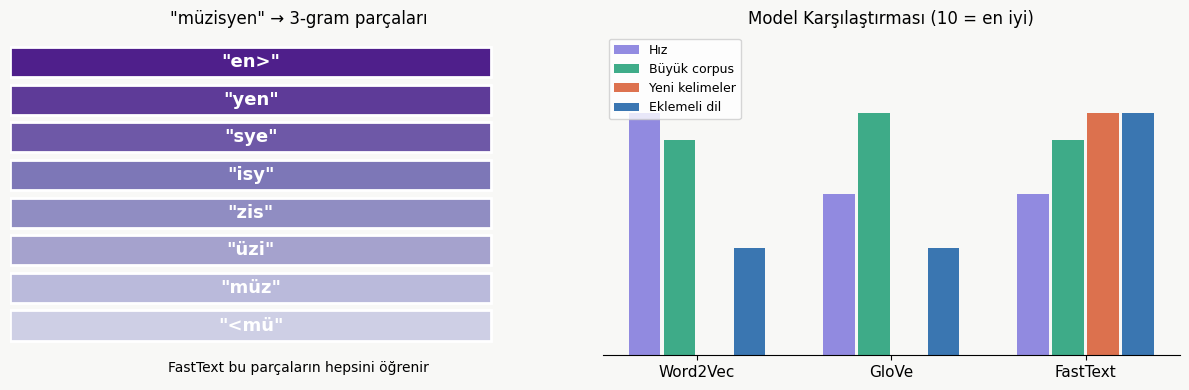

✅ Grafik kaydedildi: model_karsilastirma.png


In [32]:
# N-gram karşılaştırma görseli
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#f8f8f6")

# Sol: FastText n-gram parçaları
ax = axes[0]
ax.set_facecolor("#f8f8f6")
kelime_ornek = "müzisyen"
ngrams = []
n = 3
padded = "<" + kelime_ornek + ">"
for i in range(len(padded) - n + 1):
    ngrams.append(padded[i:i+n])

renkler_ng = plt.cm.Purples(np.linspace(0.3, 0.9, len(ngrams)))
for i, (ng, renk) in enumerate(zip(ngrams, renkler_ng)):
    ax.barh(i, 1, color=renk, edgecolor="white", linewidth=2)
    ax.text(0.5, i, f'"{ng}"', va="center", ha="center", fontsize=13,
            fontweight="bold", color="white")

ax.set_xlim(0, 1.2)
ax.set_yticks([])
ax.set_title(f'"{kelime_ornek}" → 3-gram parçaları', fontsize=12)
ax.set_xlabel("FastText bu parçaların hepsini öğrenir")
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.set_xticks([])

# Sağ: Model karşılaştırma tablosu (bar chart)
ax2 = axes[1]
ax2.set_facecolor("#f8f8f6")

modeller = ["Word2Vec", "GloVe", "FastText"]
ozellikler = {
    "Hız":               [9, 6, 6],
    "Büyük corpus":      [8, 9, 8],
    "Yeni kelimeler":    [0, 0, 9],
    "Eklemeli dil":      [4, 4, 9],
}

x = np.arange(len(modeller))
genislik = 0.18
renkler_bar = ["#7F77DD", "#1D9E75", "#D85A30", "#185FA5"]

for i, (ozellik, skorlar) in enumerate(ozellikler.items()):
    offset = (i - 1.5) * genislik
    bars = ax2.bar(x + offset, skorlar, genislik * 0.9,
                   label=ozellik, color=renkler_bar[i], alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(modeller, fontsize=11)
ax2.set_yticks([])
ax2.set_ylim(0, 12)
ax2.set_title("Model Karşılaştırması (10 = en iyi)", fontsize=12)
ax2.legend(loc="upper left", fontsize=9)
ax2.spines[["top","right","left"]].set_visible(False)
ax2.grid(axis="y", alpha=0.2, linestyle="--")

plt.tight_layout()
plt.savefig("model_karsilastirma.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: model_karsilastirma.png")

## 📋 6. Özet

| Model | Nasıl Çalışır | Güçlü Yön | Zayıf Yön |
|-------|--------------|-----------|-----------|
| **Word2Vec** | Yerel pencere (CBOW/Skip-gram) | Hızlı, basit | Bilinmeyen kelime yok |
| **GloVe** | Global birlikte-geçme matrisi | Büyük corpus | Bellek ağır |
| **FastText** | Alt-kelime (n-gram) | Yeni kelimeler, eklemeli dil | Daha yavaş |

### Ne Zaman Hangisini Kullanmalı?
- **Word2Vec** → Hız öncelikliyse, büyük genel corpus
- **GloVe** → Hazır vektör indirmek istiyorsanız (glove-wiki vb.)
- **FastText** → **Türkçe**, nadir kelimeler, morfolojik zengin diller


In [33]:
print("🎉 Notebook tamamlandı!")
print()
print("Sırada ne öğrenebilirsiniz:")
print("  → Transformer tabanlı: BERT, GPT, Sentence-BERT")
print("  → Göreve özgü fine-tuning")
print("  → Türkçe için: BERTurk, mBERT, multilingual FastText")


🎉 Notebook tamamlandı!

Sırada ne öğrenebilirsiniz:
  → Transformer tabanlı: BERT, GPT, Sentence-BERT
  → Göreve özgü fine-tuning
  → Türkçe için: BERTurk, mBERT, multilingual FastText
